In [105]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
## Disk parameters
alpha = 1e-3
M_disk = 0.1 # M_sun
T_0 = 18.9737 # K
a_c = 50 # AU
d2g = 0.01
D = 0.2
b_tilde = 10
mu = 2.33

## Star parameters
M_star = 1.0 # M_sun
R_star = 2.5 # R_sun
T_eff = 4000 # K

## Planetesimal parameters
rho_pltsml = 2.0 # g/cm^3
R_pltsml = 100 # km

## Embryo core parameters
rho_core = 2.0 # g/cm^3

## Constants
G = 6.67e-8 # cm^3/g/s^2
k_B = 1.38e-16 # erg/K
sigma_B = 5.67e-5 # erg/cm^2/s/K^4
m_H = 1.67e-24 # g
M_earth = 5.97e27 # g
M_sun = 1.99e33 # g
R_sun = 6.96e10 # cm
L_sun = 3.839e33 # erg/s
AU = 1.496e13 # cm
year = 3.156e7 # s
sigma_H2 = 2.61e-15 # cm^2

In [107]:
## Disk structure helper functions

def Sigma_0(M_disk, a_c):
    """Calculates the normalization constant for the surface density profile."""
    return M_disk * M_sun / (2 * np.pi * (a_c * AU) ** 2)

def Sigma_g(a):
    """Calculates the gas surface density of the disk in g/cm^2."""
    return Sigma_0(M_disk, a_c) * (a / a_c) ** (-1) * np.exp(-a / a_c)

def Sigma_s(a):
    """Calculates the solid surface density of the disk in g/cm^2."""
    return d2g * Sigma_g(a)

def rho_mid(a):
    """Calculates the midplane gas density of the disk in g/cm^3."""
    return Sigma_g(a) / (np.sqrt(2 * np.pi) * H(a) * AU)

def T(a):
    """Calculates the temperature of the disk in K."""
    return T_0 * (a / a_c) ** (-0.5)

def c_s(a):
    """Calculates the sound speed of the disk in cm/s."""
    return np.sqrt(k_B * T(a) / (mu * m_H))

def H(a):
    """Calculates the scale height of the disk in AU."""
    return c_s(a) / Omega_K(a) / AU

## Embryo and planetesimal helper functions

def M_pltsml(R_pltsml):
    """Calculates the mass of a planetesimal assuming constant density in Earth masses."""
    return (4/3) * np.pi * (R_pltsml * 1e5) ** 3 * rho_pltsml / M_earth

def Omega_K(a):
    """Calculates the Keplerian angular velocity in rad/s."""
    return np.sqrt(G * M_star * M_sun / (a * AU) ** 3)

def R_core(M_core):
    """Calculates the core radius assuming a constant density in km."""
    return (3 * M_core * M_earth / (4 * np.pi * rho_core)) ** (1/3) / 1e5

def R_H(M_core, a_core):
    """Calculates the Hill radius in AU."""
    return a_core * (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

## Planetesimal accretion helper functions

def e_tilde_embryo(e2, M_core):
    """Calculates the embryo reduced eccentricity."""
    return np.sqrt(np.maximum(e2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def i_tilde_embryo(i2, M_core):
    """Calculates the embryo reduced inclination."""
    return np.sqrt(np.maximum(i2, 0)) / (M_core * M_earth / (3 * M_star * M_sun)) ** (1/3)

def I_F(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.95925 * beta + 0.77251 * beta ** 2) / (beta * (0.13142 + 0.12295 * beta))

def I_G(beta):
    """Numerical elliptic integral approximation (Fortier et al 2012)."""
    return (1 + 0.3996 * beta) / (beta * (0.0369 + 0.048333 * beta + 0.006874 * beta ** 2))

def P_high(e2, i2, a_core, M_core):
    """Calculates the high collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml * 1e5) ** 2 / (2 * np.pi * (R_H(M_core, a_core) * AU) ** 2)) * (I_F(beta) + 6 * R_H(M_core, a_core) * AU * I_G(beta) / ((R_core(M_core) * 1e5 + R_pltsml * 1e5) * e_tilde ** 2))

def P_med(e2, i2, a_core, M_core):
    """Calculates the medium collisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return ((R_core(M_core) * 1e5 + R_pltsml * 1e5) ** 2 / (4 * np.pi * (R_H(M_core, a_core) * AU) ** 2) * i_tilde) * (17.3 + 232 * R_H(M_core, a_core) * AU / (R_core(M_core) * 1e5 + R_pltsml * 1e5))

def P_low(e2, i2, a_core, M_core):
    """Calculates the low colisional rate (Fortier et al 2012)."""
    e_tilde = e_tilde_embryo(e2, M_core)
    i_tilde = i_tilde_embryo(i2, M_core)
    beta = i_tilde / e_tilde
    return 11.3 * ((R_core(M_core) * 1e5 + R_pltsml * 1e5) / (R_H(M_core, a_core) * AU)) ** (1/2)

def P_coll(e2, i2, a_core, M_core):
    """Calculates the probability that the planetesimal is accreted by the embryo (Fortier et al 2012)."""
    return np.min((P_med(e2, i2, a_core, M_core), (P_high(e2, i2, a_core, M_core) ** (-2) + P_low(e2, i2, a_core, M_core) ** (-2)) ** (-1/2)), axis = 0)

In [108]:
## Planetesimal accretion rates (Fortier et al 2012)

def dM_dt(e2, i2, a_core, M_core):
    """Calculates the planetesimal core accretion rate in M_earth/s (Fortier et al 2012)."""
    return Sigma_s(a_core) * Omega_K(a_core) * (R_H(M_core, a_core) * AU) ** 2 * P_coll(e2, i2, a_core, M_core) / M_earth

In [109]:
## Equilibrium eccentricity

def e_eq_VS_embryo(a_0, M_core):
    """Calculates the equilibrium eccentricity by balancing embryo stirring with gas drag (Fortier et al 2012)"""
    return 1.7 * (M_pltsml(R_pltsml) * M_earth) ** (1/15) * (M_core * M_earth) ** (1/3) * rho_pltsml ** (2/15) / (b_tilde ** (1/5) * D ** (1/5) * rho_mid(a_0) ** (1/5) * (M_star * M_sun) ** (1/3) * (a_0 * AU) ** (1/5))

def e_eq_VS_pltsml(a_0):
    """Calculates the equilibrium eccentrictiy by balancing planetesimal self stirring with gas drag (Fortier et al 2012)"""
    return 2.31 * (M_pltsml(R_pltsml) * M_earth) ** (4/15) * (a_0 * AU) ** (1/5) * rho_pltsml ** (2/15) * Sigma_s(a_0) ** (1/5) / (D ** (1/5) * rho_mid(a_0) ** (1/5) * (M_star * M_sun) ** (2/5))

## Isolation mass

def M_iso(a_core):
    """Calculates the isolation mass in terms of Earth masses."""
    return (2 * np.pi * (a_core * AU) ** 2 * b_tilde * Sigma_s(a_core)) ** (3/2) * (3 * M_star * M_sun) ** (-1/2) / M_earth

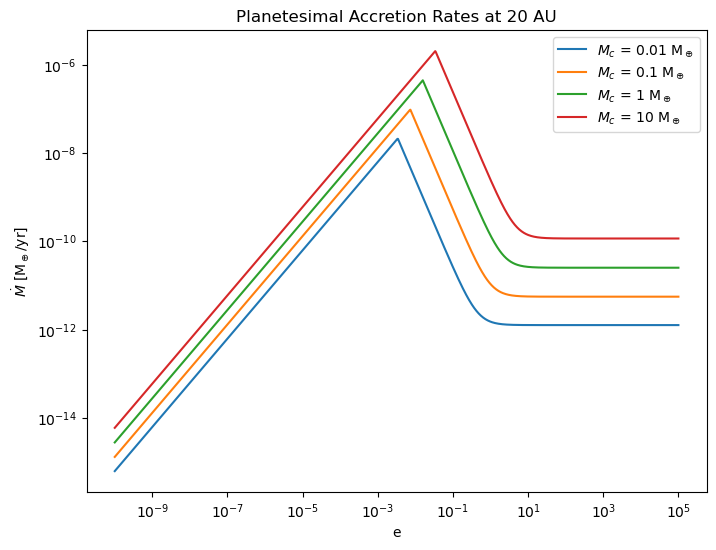

In [110]:
## Plot dM/dt vs e

fig, ax = plt.subplots(figsize = (8, 6))

eccentricity = np.logspace(-10, 5, 1000)
M_cores = [0.01, 0.1, 1, 10] # M_earth
a_core = 20 # AU

for M_core in M_cores:
    Mdot_values = [dM_dt(e ** 2, (e / 2) ** 2, a_core, M_core) * year for e in eccentricity]
    ax.plot(eccentricity, Mdot_values, label = fr'$M_c$ = {M_core} M$_\oplus$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'e')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a_core} AU')
ax.legend()
plt.show()

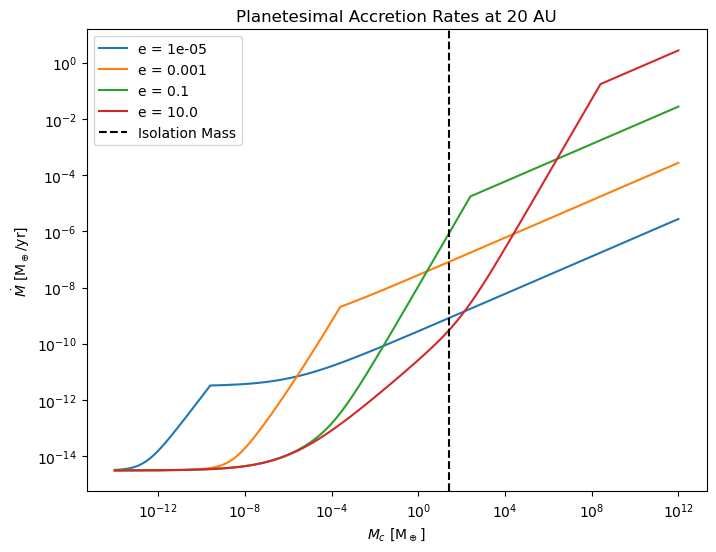

In [111]:
## Plot dM/dt vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

eccentricity = [1e-5, 1e-3, 1e-1, 1e1] # cm/s
M_cores = np.logspace(-14, 12, 1000) # M_earth
a_core = 20 # AU

for e in eccentricity:
    Mdot_values = [dM_dt(e ** 2, (e / 2) ** 2, a_core, M_core) * year for M_core in M_cores]
    ax.plot(M_cores, Mdot_values, label = fr'e = {e}')

## Isolation mass
plt.axvline(M_iso(a_core), color = 'black', linestyle = '--', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a_core} AU')
ax.legend(loc = 'upper left')
plt.show()

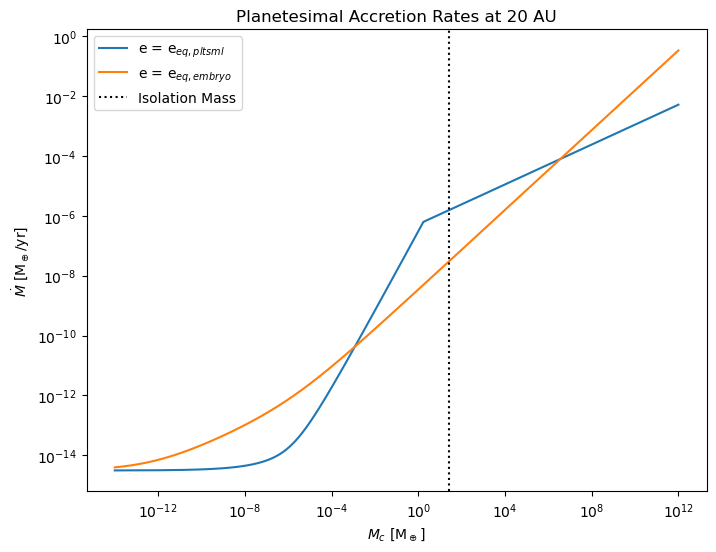

In [112]:
## Plot dM/dt vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

M_cores = np.logspace(-14, 12, 1000) # M_earth
a = 20 # AU
R_pltsml = 100 # km

e_pltsml = [e_eq_VS_pltsml(a) for _ in M_cores]
e_embryo = [e_eq_VS_embryo(a, M) for M in M_cores]

Mdot_pltsml_values = [dM_dt(e ** 2, (e / 2) ** 2, a, M) * year for e, M in zip(e_pltsml, M_cores)]
Mdot_embryo_values = [dM_dt(e ** 2, (e / 2) ** 2, a, M) * year for e, M in zip(e_embryo, M_cores)]

ax.plot(M_cores, Mdot_pltsml_values, label = r'e = e$_{eq, pltsml}$')
ax.plot(M_cores, Mdot_embryo_values, label = r'e = e$_{eq, embryo}$')

## Isolation mass
plt.axvline(M_iso(a), color = 'black', linestyle = ':', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a} AU')
ax.legend(loc = 'upper left')
plt.show()

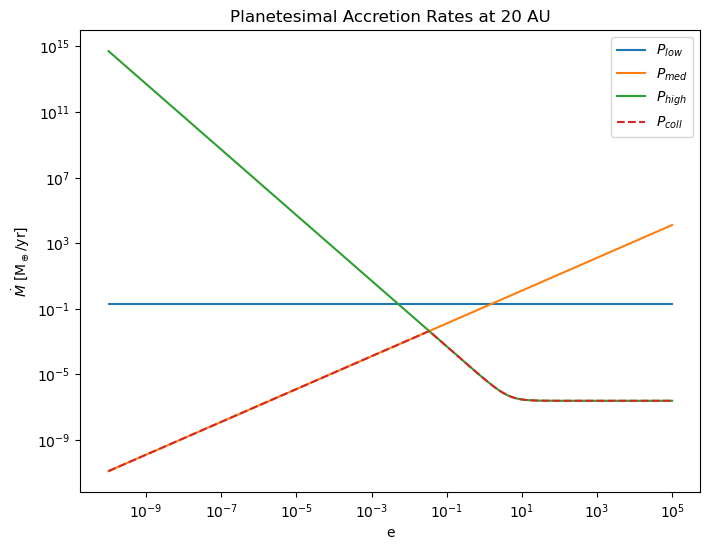

In [113]:
## Plot P_coll vs e

fig, ax = plt.subplots(figsize = (8, 6))

eccentricity = np.logspace(-10, 5, 1000)
M_cores = [0.1] # M_earth
a_core = 20 # AU

P_low_vals = [P_low(e ** 2, (e / 2) ** 2, a_core, M_core) for e in eccentricity]
P_med_vals = [P_med(e ** 2, (e / 2) ** 2, a_core, M_core) for e in eccentricity]
P_high_vals = [P_high(e ** 2, (e / 2) ** 2, a_core, M_core) for e in eccentricity]
P_coll_vals = [P_coll(e ** 2, (e / 2) ** 2, a_core, M_core) for e in eccentricity]
ax.plot(eccentricity, P_low_vals, label = r'$P_{low}$')
ax.plot(eccentricity, P_med_vals, label = r'$P_{med}$')
ax.plot(eccentricity, P_high_vals, label = r'$P_{high}$')
ax.plot(eccentricity, P_coll_vals, linestyle = '--', label = r'$P_{coll}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'e')
ax.set_ylabel(r'$\dot{M}$ [M$_\oplus$/yr]')
plt.title(f'Planetesimal Accretion Rates at {a_core} AU')
ax.legend()
plt.show()

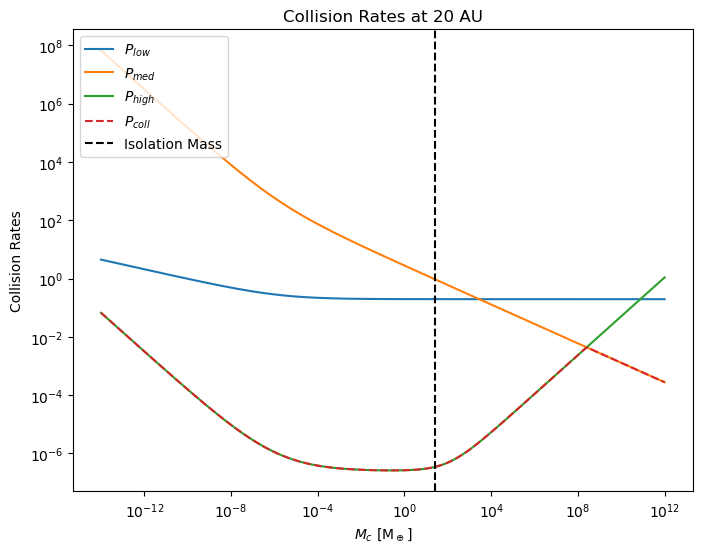

In [114]:
## Plot P_coll vs M_core

fig, ax = plt.subplots(figsize = (8, 6))

eccentricity = 0.1
M_cores = np.logspace(-14, 12, 1000) # M_earth
a_core = 20 # AU

P_low_vals = [P_low(e ** 2, (e / 2) ** 2, a_core, M_core) for M_core in M_cores]
P_med_vals = [P_med(e ** 2, (e / 2) ** 2, a_core, M_core) for M_core in M_cores]
P_high_vals = [P_high(e ** 2, (e / 2) ** 2, a_core, M_core) for M_core in M_cores]
P_coll_vals = [P_coll(e ** 2, (e / 2) ** 2, a_core, M_core) for M_core in M_cores]
ax.plot(M_cores, P_low_vals, label = r'$P_{low}$')
ax.plot(M_cores, P_med_vals, label = r'$P_{med}$')
ax.plot(M_cores, P_high_vals, label = r'$P_{high}$')
ax.plot(M_cores, P_coll_vals, linestyle = '--', label = r'$P_{coll}$')

## Isolation mass
plt.axvline(M_iso(a_core), color = 'black', linestyle = '--', label = 'Isolation Mass')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_c$ [M$_\oplus$]')
ax.set_ylabel(r'Collision Rates')
plt.title(f'Collision Rates at {a_core} AU')
ax.legend(loc = 'upper left')
plt.show()